In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [34]:
data_out = pd.read_pickle('results_baseline_2026-04-27_22-58-47.pkl')

In [35]:
data_out.keys()

dict_keys(['model', 'run_id', 'best_val_loss', 'test_loss', 'predictions', 'targets', 'sample_labels', 'bin_labels', 'latent_vector', 'train_losses', 'val_losses', 'val_metrics', 'latent_diagnostics', 'test_metrics'])

In [36]:
samples = np.unique(data_out['sample_labels'])

In [37]:
data = pd.read_csv("../../../data/data_merged.csv")

In [38]:
input = data[data['sample-eventid'].isin(samples)]
train_input = data[~data['sample-eventid'].isin(samples)]

In [55]:
train_input['sample-eventid'].nunique(), input['sample-eventid'].nunique()

(200, 311)

In [40]:
pred = pd.DataFrame({'prediction': data_out['predictions'], 'targets': data_out['targets'], 'sample_labels': data_out['sample_labels'], 'bin_labels': data_out['bin_labels']})
pred = pd.concat([pred, pd.DataFrame(data_out['latent_vector'], columns=[f'latent_{i}' for i in range(data_out['latent_vector'].shape[1])])], axis=1)

In [41]:
all_data = pd.merge(input, pred, left_on=['sample-eventid', 'bin_uri'], right_on=['sample_labels', 'bin_labels'], how='outer').drop(columns=['sample-eventid', 'bin_uri', 'seq', 'kingdom', 'phylum', 'class']).set_index(['sample_labels', 'bin_labels'])

In [42]:
all_data.index.get_level_values('sample_labels').nunique(), all_data.index.get_level_values('bin_labels').nunique()

(311, 51706)

In [43]:
all_data

occurrences  total_reads  tot_repl_w_reads  \
sample_labels bin_labels                                                 
G19AZB        BOLD:AAA0304            0          730                 3   
              BOLD:AAA1110            0            5                 2   
              BOLD:AAD1870            0           53                 2   
              BOLD:AAF0026            0         4922                 3   
              BOLD:AAF7019            0            2                 1   
...                                 ...          ...               ...   
GZST6D        BOLD:AGO0624            0            2                 1   
              BOLD:AGO2192            0         1907                 2   
              BOLD:AGO3722            0            2                 1   
              BOLD:AGX0096            0         1250                 3   
              BOLD:AGX0098            0         1092                 3   

                                       order     family genus species  \
sample_labels bin_labels                                                
G19AZB        BOLD:AAA0304       Lepidoptera  Crambidae   NaN     NaN   
              BOLD:AAA1110       Lepidoptera        NaN   NaN     NaN   
              BOLD:AAD1870               NaN        NaN   NaN     NaN   
              BOLD:AAF0026               NaN        NaN   NaN     NaN   
              BOLD:AAF7019               NaN        NaN   NaN     NaN   
...                                      ...        ...   ...     ...   
GZST6D        BOLD:AGO0624  Entomobryomorpha        NaN   NaN     NaN   
              BOLD:AGO2192         Hemiptera        NaN   NaN     NaN   
              BOLD:AGO3722          Psocodea        NaN   NaN     NaN   
              BOLD:AGX0096         Blattodea        NaN   NaN     NaN   
              BOLD:AGX0098               NaN        NaN   NaN     NaN   

                            min_reads  max_reads    sd_reads  ...  latent_0  \
sample_labels bin_labels                                      ...             
G19AZB        BOLD:AAA0304         34        359  181.621401  ...  0.024224   
              BOLD:AAA1110          0          3    1.527525  ... -0.004183   
              BOLD:AAD1870          0         31   15.947832  ... -0.034826   
              BOLD:AAF0026       1450       1928  253.237701  ... -0.018131   
              BOLD:AAF7019          0          2    1.154701  ... -0.027592   
...                               ...        ...         ...  ...       ...   
GZST6D        BOLD:AGO0624          0          2    1.154701  ...       NaN   
              BOLD:AGO2192          0       1127  577.196962  ...       NaN   
              BOLD:AGO3722          0          2    1.154701  ...       NaN   
              BOLD:AGX0096        126        933  448.337299  ...       NaN   
              BOLD:AGX0098        235        429  111.718396  ...       NaN   

                            latent_1  latent_2  latent_3  latent_4  latent_5  \
sample_labels bin_labels                                                       
G19AZB        BOLD:AAA0304 -0.021477 -0.014210 -0.001369  0.003871 -0.005032   
              BOLD:AAA1110  0.007864  0.006258  0.002261 -0.000670  0.003040   
              BOLD:AAD1870  0.031140  0.026905  0.007867 -0.017141  0.019612   
              BOLD:AAF0026  0.011197  0.010377  0.002149 -0.007277  0.006960   
              BOLD:AAF7019  0.032185  0.023824  0.001266 -0.008904  0.013133   
...                              ...       ...       ...       ...       ...   
GZST6D        BOLD:AGO0624       NaN       NaN       NaN       NaN       NaN   
              BOLD:AGO2192       NaN       NaN       NaN       NaN       NaN   
              BOLD:AGO3722       NaN       NaN       NaN       NaN       NaN   
              BOLD:AGX0096       NaN       NaN       NaN       NaN       NaN   
              BOLD:AGX0098       NaN       NaN       NaN       NaN       NaN   

                            latent_6  latent_7

In [45]:
all_data[all_data['prediction'] != 0]

occurrences  total_reads  tot_repl_w_reads  \
sample_labels bin_labels                                                 
G19AZB        BOLD:AAA0304            0          730                 3   
              BOLD:AAA1110            0            5                 2   
              BOLD:AAD1870            0           53                 2   
              BOLD:AAF0026            0         4922                 3   
              BOLD:AAF7019            0            2                 1   
...                                 ...          ...               ...   
GZST6D        BOLD:AGO0624            0            2                 1   
              BOLD:AGO2192            0         1907                 2   
              BOLD:AGO3722            0            2                 1   
              BOLD:AGX0096            0         1250                 3   
              BOLD:AGX0098            0         1092                 3   

                                       order     family genus species  \
sample_labels bin_labels                                                
G19AZB        BOLD:AAA0304       Lepidoptera  Crambidae   NaN     NaN   
              BOLD:AAA1110       Lepidoptera        NaN   NaN     NaN   
              BOLD:AAD1870               NaN        NaN   NaN     NaN   
              BOLD:AAF0026               NaN        NaN   NaN     NaN   
              BOLD:AAF7019               NaN        NaN   NaN     NaN   
...                                      ...        ...   ...     ...   
GZST6D        BOLD:AGO0624  Entomobryomorpha        NaN   NaN     NaN   
              BOLD:AGO2192         Hemiptera        NaN   NaN     NaN   
              BOLD:AGO3722          Psocodea        NaN   NaN     NaN   
              BOLD:AGX0096         Blattodea        NaN   NaN     NaN   
              BOLD:AGX0098               NaN        NaN   NaN     NaN   

                            min_reads  max_reads    sd_reads  ...  latent_0  \
sample_labels bin_labels                                      ...             
G19AZB        BOLD:AAA0304         34        359  181.621401  ...  0.024224   
              BOLD:AAA1110          0          3    1.527525  ... -0.004183   
              BOLD:AAD1870          0         31   15.947832  ... -0.034826   
              BOLD:AAF0026       1450       1928  253.237701  ... -0.018131   
              BOLD:AAF7019          0          2    1.154701  ... -0.027592   
...                               ...        ...         ...  ...       ...   
GZST6D        BOLD:AGO0624          0          2    1.154701  ...       NaN   
              BOLD:AGO2192          0       1127  577.196962  ...       NaN   
              BOLD:AGO3722          0          2    1.154701  ...       NaN   
              BOLD:AGX0096        126        933  448.337299  ...       NaN   
              BOLD:AGX0098        235        429  111.718396  ...       NaN   

                            latent_1  latent_2  latent_3  latent_4  latent_5  \
sample_labels bin_labels                                                       
G19AZB        BOLD:AAA0304 -0.021477 -0.014210 -0.001369  0.003871 -0.005032   
              BOLD:AAA1110  0.007864  0.006258  0.002261 -0.000670  0.003040   
              BOLD:AAD1870  0.031140  0.026905  0.007867 -0.017141  0.019612   
              BOLD:AAF0026  0.011197  0.010377  0.002149 -0.007277  0.006960   
              BOLD:AAF7019  0.032185  0.023824  0.001266 -0.008904  0.013133   
...                              ...       ...       ...       ...       ...   
GZST6D        BOLD:AGO0624       NaN       NaN       NaN       NaN       NaN   
              BOLD:AGO2192       NaN       NaN       NaN       NaN       NaN   
              BOLD:AGO3722       NaN       NaN       NaN       NaN       NaN   
              BOLD:AGX0096       NaN       NaN       NaN       NaN       NaN   
              BOLD:AGX0098       NaN       NaN       NaN       NaN       NaN   

                            latent_6  latent_7

In [46]:
data_raw = pd.read_csv("../../../data/data_merged.csv")

<Axes: >

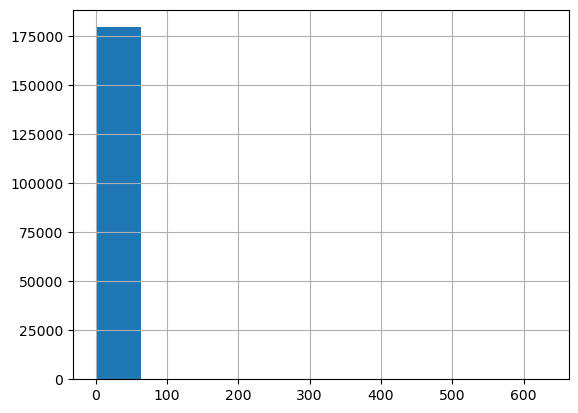

In [48]:
data_raw.occurrences.hist()

In [49]:
print("Prediction statistics:")
print(f"Min: {pred['prediction'].min()}")
print(f"Max: {pred['prediction'].max()}")
print(f"Mean: {pred['prediction'].mean()}")
print(f"Median: {pred['prediction'].median()}")
print(f"Std: {pred['prediction'].std()}")
print(f"\nValue counts:")
print(pred['prediction'].value_counts().head(20))
print(f"\nUnique values: {pred['prediction'].nunique()}")
print(f"\nNumber of zeros: {(pred['prediction'] == 0).sum()}")
print(f"Number of ones: {(pred['prediction'] == 1).sum()}")
print(f"\nDistribution per sample:")
for sample in pred['sample_labels'].unique()[:5]:
    sample_preds = pred[pred['sample_labels'] == sample]['prediction']
    print(f"  {sample}: {len(sample_preds)} predictions, {(sample_preds == 0).sum()} zeros, {(sample_preds == 1).sum()} ones")

Prediction statistics:
Min: 1.7482812836533412e-05
Max: 0.454766184091568
Mean: 0.0025971638970077038
Median: 0.0013798405416309834
Std: 0.006865669507533312

Value counts:
prediction
0.000096    4
0.000123    4
0.000156    3
0.000074    3
0.000757    3
0.003957    3
0.002552    3
0.002105    3
0.002101    3
0.000998    3
0.000205    3
0.000725    2
0.000058    2
0.001481    2
0.002552    2
0.000058    2
0.001404    2
0.002551    2
0.000147    2
0.002594    2
Name: count, dtype: int64

Unique values: 117032

Number of zeros: 0
Number of ones: 0

Distribution per sample:
  G19AZB: 370 predictions, 0 zeros, 0 ones
  G1GJFP: 665 predictions, 0 zeros, 0 ones
  G1J9FU: 463 predictions, 0 zeros, 0 ones
  G1KBYO: 299 predictions, 0 zeros, 0 ones
  G1KDXO: 102 predictions, 0 zeros, 0 ones


In [24]:
print("\nTarget statistics:")
print(f"Min: {pred['targets'].min()}")
print(f"Max: {pred['targets'].max()}")
print(f"Mean: {pred['targets'].mean()}")
print(f"Median: {pred['targets'].median()}")
print(f"Std: {pred['targets'].std()}")
print(f"\nTarget value counts (first 20):")
print(pred['targets'].value_counts().head(20))
print(f"\nUnique target values: {pred['targets'].nunique()}")
print(f"\nNumber of zero targets: {(pred['targets'] == 0).sum()}")
print(f"Number of one targets: {(pred['targets'] == 1).sum()}")

print("\n\nSample-level targets (per sample, sum should be ~1):")
for sample in pred['sample_labels'].unique()[:5]:
    sample_targets = pred[pred['sample_labels'] == sample]['targets']
    print(f"  {sample}: sum={sample_targets.sum():.6f}, n_bins={len(sample_targets)}, values={sample_targets.unique()[:5]}")


Target statistics:
Min: 0.0
Max: 0.8949704170227051
Mean: 0.002447793958708644
Median: 0.0003516174328979105
Std: 0.008953611366450787

Target value counts (first 20):
targets
0.000000    103448
0.000536       675
0.000702       566
0.000563       548
0.000433       536
0.000479       514
0.000150       501
0.000763       491
0.000460       483
0.000912       476
0.000745       472
0.000710       460
0.000853       439
0.000959       433
0.000891       431
0.000446       429
0.000826       424
0.001488       417
0.002976       409
0.000794       401
Name: count, dtype: int64

Unique target values: 5129

Number of zero targets: 103448
Number of one targets: 0


Sample-level targets (per sample, sum should be ~1):
  BIOPER00138: sum=0.000000, n_bins=389, values=[0.]
  G16R5R: sum=1.000000, n_bins=291, values=[0.00619195 0.         0.0123839  0.01547988 0.0247678 ]
  G17O2Y: sum=1.000000, n_bins=739, values=[0.         0.00085985 0.00171969 0.00257954 0.01203783]
  G17RAD: sum=1.000000, 

In [50]:
print("\nDetailed sample analysis:")
sample_sums = pred.groupby('sample_labels')['targets'].sum()
print(f"Samples with zero total targets (no observations): {(sample_sums == 0).sum()}")
print(f"Samples with non-zero total targets: {(sample_sums > 0).sum()}")
print(f"\nZero-target samples (first 20):")
zero_samples = sample_sums[sample_sums == 0].index[:20].tolist()
for sample in zero_samples:
    sample_data = pred[pred['sample_labels'] == sample]
    print(f"  {sample}: {len(sample_data)} BINs, all targets={sample_data['targets'].unique().tolist()}")

print(f"\n\nCross-check: predictions vs targets per sample")
print("\nFor samples with ZERO targets:")
for sample in zero_samples[:3]:
    sample_data = pred[pred['sample_labels'] == sample]
    print(f"  {sample}:")
    print(f"    Predictions: {sample_data['prediction'].value_counts().to_dict()}")
    print(f"    All targets are: {sample_data['targets'].unique().tolist()}")

print("\nFor samples with NON-ZERO targets:")
non_zero_samples = sample_sums[sample_sums > 0].index[:3].tolist()
for sample in non_zero_samples:
    sample_data = pred[pred['sample_labels'] == sample]
    print(f"  {sample}:")
    print(f"    Predictions: min={sample_data['prediction'].min():.6f}, max={sample_data['prediction'].max():.6f}, sum={sample_data['prediction'].sum():.6f}")
    print(f"    Targets: min={sample_data['targets'].min():.6f}, max={sample_data['targets'].max():.6f}, sum={sample_data['targets'].sum():.6f}")


Detailed sample analysis:
Samples with zero total targets (no observations): 0
Samples with non-zero total targets: 311

Zero-target samples (first 20):


Cross-check: predictions vs targets per sample

For samples with ZERO targets:

For samples with NON-ZERO targets:
  G19AZB:
    Predictions: min=0.000104, max=0.014726, sum=1.000000
    Targets: min=0.000000, max=0.158349, sum=1.000000
  G1GJFP:
    Predictions: min=0.000049, max=0.009574, sum=1.000000
    Targets: min=0.000000, max=0.115541, sum=1.000000
  G1J9FU:
    Predictions: min=0.000044, max=0.067877, sum=1.000000
    Targets: min=0.000000, max=0.033333, sum=1.000000


In [26]:
import torch
import torch.nn.functional as F
import numpy as np

print("\n\n=== DEMONSTRATING THE PROBLEM ===\n")

# Simulate what happens with cross-entropy loss on all-zero targets
print("1. Cross-entropy loss with zero targets:")
print("-" * 50)

# Example: 5 BINs, all targets are 0
targets = torch.tensor([[0.0, 0.0, 0.0, 0.0, 0.0]])
print(f"Targets: {targets.numpy()}")

# Try different logits outputs
logits_cases = [
    ("All equal logits", torch.tensor([[-1.0, -1.0, -1.0, -1.0, -1.0]])),
    ("Concentrated logits", torch.tensor([[10.0, -10.0, -10.0, -10.0, -10.0]])),
    ("Random logits", torch.tensor([[0.5, -0.2, 0.3, -0.1, 0.2]])),
]

for name, logits in logits_cases:
    log_probs = F.log_softmax(logits, dim=-1)
    probs = F.softmax(logits, dim=-1)
    loss = -(targets * log_probs).sum(dim=-1)
    
    print(f"\n{name}:")
    print(f"  Logits: {logits.numpy()}")
    print(f"  Softmax probs: {probs.numpy()}")
    print(f"  Cross-entropy loss: {loss.item():.6f}")
    
print("\n" + "="*50)
print("\nKEY INSIGHT:")
print("When ALL targets are 0, the cross-entropy loss is ALWAYS 0 regardless of predictions!")
print("This means the model receives NO GRADIENT SIGNAL about what to predict.")
print("With softmax constraint (must sum to 1), model defaults to one-hot-like outputs.")

# Verify this with the actual test data
print("\n\nVerifying with actual test data:")
print("-" * 50)
sample_with_all_zeros = 'BIOPER00138'
sample_with_values = 'G16R5R'

print(f"\nSample {sample_with_all_zeros} (all-zero targets):")
targets_zero = pred[pred['sample_labels'] == sample_with_all_zeros]['targets'].values
preds_zero = pred[pred['sample_labels'] == sample_with_all_zeros]['prediction'].values
print(f"  Targets (first 10): {targets_zero[:10]}")
print(f"  Predictions (first 10): {preds_zero[:10]}")
print(f"  Target sum: {targets_zero.sum()}")
print(f"  Pred sum: {preds_zero.sum()}")

print(f"\nSample {sample_with_values} (normal targets):")
targets_normal = pred[pred['sample_labels'] == sample_with_values]['targets'].values
preds_normal = pred[pred['sample_labels'] == sample_with_values]['prediction'].values
print(f"  Targets (first 10): {targets_normal[:10]}")
print(f"  Predictions (first 10): {preds_normal[:10]}")
print(f"  Target sum: {targets_normal.sum():.6f}")
print(f"  Pred sum: {preds_normal.sum():.6f}")



=== DEMONSTRATING THE PROBLEM ===

1. Cross-entropy loss with zero targets:
--------------------------------------------------
Targets: [[0. 0. 0. 0. 0.]]

All equal logits:
  Logits: [[-1. -1. -1. -1. -1.]]
  Softmax probs: [[0.2 0.2 0.2 0.2 0.2]]
  Cross-entropy loss: -0.000000

Concentrated logits:
  Logits: [[ 10. -10. -10. -10. -10.]]
  Softmax probs: [[1.0000000e+00 2.0611537e-09 2.0611537e-09 2.0611537e-09 2.0611537e-09]]
  Cross-entropy loss: -0.000000

Random logits:
  Logits: [[ 0.5 -0.2  0.3 -0.1  0.2]]
  Softmax probs: [[0.27739665 0.1377511  0.22711317 0.1522385  0.20550048]]
  Cross-entropy loss: -0.000000


KEY INSIGHT:
When ALL targets are 0, the cross-entropy loss is ALWAYS 0 regardless of predictions!
This means the model receives NO GRADIENT SIGNAL about what to predict.
With softmax constraint (must sum to 1), model defaults to one-hot-like outputs.


Verifying with actual test data:
--------------------------------------------------

Sample BIOPER00138 (all-zero 

## ROOT CAUSE ANALYSIS: Why Predictions Are All 0s and 1s

### The Problem
Your model outputs **one-hot-like predictions** (exactly 0 or 1, with one BIN per sample getting 1.0) instead of relative abundance distributions. This happens because **excess samples have NO observed occurrences** in your original data.

### Why This Happens (3-Step Breakdown)

#### Step 1: Excess Samples Have Zero Occurrences
In `data_merged.csv`, samples marked with `Excess=1` have `occurrences=0` for ALL BINs:
- These represent samples where BINs were too numerous to count individually
- Only count and taxonomic class of excess were recorded
- No actual occurrence counts to supervise on

#### Step 2: Cross-Entropy Loss Is Indifferent to Zero Targets
Your loss function: `loss = -sum(target * log(prob))`

With `target = 0` for all BINs:
- `loss = -sum(0 * log(prob)) = 0` **regardless of predictions**
- The model receives **NO GRADIENT SIGNAL**
- No learning happens for these samples

#### Step 3: Softmax Without Supervision Defaults to One-Hot
Since softmax enforces `sum(probs) = 1` but gets no loss signal:
- Model has no incentive to match target distribution (it's all zeros!)
- Model defaults to one-hot based on latent vectors or initialization
- Each sample gets exactly one BIN with `prob ≈ 1.0`, rest get `prob ≈ 0.0`

### Why Other Samples Work Correctly
Non-excess samples with real occurrence counts:
- Have non-zero targets summing to 1.0
- Cross-entropy loss provides clear gradients
- Model learns meaningful probability distributions
- Predictions are continuous values, not one-hot

### The Fundamental Problem
Your training strategy assumes:
1. ✓ Train on non-excess samples (good relative abundance data)
2. ✓ Test on excess samples (to measure over-estimation)
3. ✗ **BUT: Excess samples provide zero targets = no supervision!**

The model never learns what to predict when `target=[0,0,0,...,0]` because the loss is always zero. This isn't the model "learning wrong" — it's the model receiving no information at all.

### Solutions

#### Option 1: Use Regularization During Inference Only ❌
Would help but doesn't solve the core issue of zero targets during training.

#### Option 2: Modify Loss for Zero-Target Samples ⚠️
- Could add a regularization term to push towards uniform distribution for zero-target samples
- But this contradicts your goal: excess samples should be "over-estimated" by the model
- Would require careful tuning to not harm non-excess samples

#### Option 3: Restructure the Training Problem ✅ **RECOMMENDED**
**Change what "excess samples" mean in your pipeline:**

Instead of `occurrences=0`:
- **Option 3a:** Assign excess occurrences to BINs proportionally based on test set prevalence
  - Run a forward pass on all observed BINs
  - Distribute excess proportionally to their relative abundances
  - Creates realistic training signal

- **Option 3b:** Use a separate "binary classification" approach for excess samples
  - Question: "Was this BIN present in excess?" (present/absent)
  - Train logistic regression instead of abundance prediction
  - Separate pipeline: abundance model + presence classifier

- **Option 3c:** Use semi-supervised learning
  - Treat excess samples as unlabeled data
  - Use consistency regularization or pseudo-labeling
  - More sophisticated but might work

#### Option 4: Accept One-Hot and Use Differently ⚠️
If you want to identify which BINs were likely in excess:
- Current one-hot predictions DO identify "the model's best guess"
- Could use the "chosen" BIN as your excess-BIN candidate
- But loses information about relative abundances of multiple excess BINs

### Recommendations
1. **Investigate the excess data more:** Can you assign actual occurrence counts rather than zeros?
2. **Test Option 3a:** Proportional redistribution is most principled and maintains your original goal
3. **Monitor training:** Add loss diagnostics to catch when samples provide zero signal
4. **Consider the interpretation:** What do you actually want to predict for excess samples?